In [5]:
import numpy as np
import pandas as pd
import scanpy as sc
import colorcet
import sklearn.neighbors
import scipy.sparse
from sklearn.neighbors import NearestNeighbors

from numpy.typing import NDArray
import umap.umap_ as umap
import matplotlib
import matplotlib.pyplot as plt

import umap
import seaborn as sns
import scipy.sparse

import metacells.parameters as pr
import metacells.utilities as ut
from scipy.sparse import load_npz


In [6]:
sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")
envi_latent_st = st_ad.obsm['envi_latent']
envi_latent_sc = sc_ad.obsm['envi_latent']

covet_sqrt_st=st_ad.obsm['COVET_SQRT']
covet_sqrt_sc=sc_ad.obsm['COVET_SQRT']

In [7]:
print(envi_latent_sc.shape)
print(envi_latent_st.shape)
print(covet_sqrt_sc.shape)
print(covet_sqrt_st.shape)

(7416, 512)
(18516, 512)
(7416, 64, 64)
(18516, 64, 64)


In [8]:
covet_sqrt_combined = np.concatenate((covet_sqrt_sc, covet_sqrt_st), axis=0)
covet_sqrt_flattened = covet_sqrt_combined.reshape(covet_sqrt_combined.shape[0], -1)

envi_latent_combined = np.concatenate((envi_latent_sc, envi_latent_st), axis=0)


In [9]:
print( covet_sqrt_flattened.shape)
print(envi_latent_combined.shape)

(25932, 4096)
(25932, 512)


In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=512)  # Reduce to match envi_latent
covet_sqrt_reduced = pca.fit_transform(covet_sqrt_flattened)

print(covet_sqrt_reduced.shape) 


(25932, 512)


In [14]:
combined_matrix = np.concatenate([envi_latent_combined, covet_sqrt_reduced], axis=1)
print(combined_matrix.shape)
print(combined_matrix)

(25932, 1024)
[[ 0.54509723  0.14981279 -0.05097356 ... -0.01600006 -0.00235486
  -0.02911469]
 [ 0.16981411  0.13461766 -0.03672996 ...  0.00464646  0.00638403
   0.00101538]
 [ 0.20032202  0.16499552  0.13389239 ...  0.00150522 -0.01047352
  -0.0062904 ]
 ...
 [-0.00809197  0.30837688  0.5936734  ...  0.04239833 -0.06042017
   0.02827439]
 [ 0.22977303 -0.25840616 -0.2031456  ...  0.10716785 -0.04704336
  -0.07200656]
 [ 0.18616462  0.04631992  0.4965636  ... -0.02440963  0.05910571
   0.03051549]]


In [17]:
import scipy.sparse as sp
n_neighbors = 15  
knn = NearestNeighbors(n_neighbors=n_neighbors, metric="euclidean").fit(combined_matrix)
knn_graph = knn.kneighbors_graph(combined_matrix, mode="connectivity")
print(knn_graph)


  (0, 0)	1.0
  (0, 6692)	1.0
  (0, 3091)	1.0
  (0, 6303)	1.0
  (0, 7002)	1.0
  (0, 805)	1.0
  (0, 7239)	1.0
  (0, 6228)	1.0
  (0, 753)	1.0
  (0, 3359)	1.0
  (0, 2876)	1.0
  (0, 3087)	1.0
  (0, 4346)	1.0
  (0, 5192)	1.0
  (0, 3952)	1.0
  (1, 1)	1.0
  (1, 7011)	1.0
  (1, 346)	1.0
  (1, 6796)	1.0
  (1, 3016)	1.0
  (1, 4280)	1.0
  (1, 3563)	1.0
  (1, 1134)	1.0
  (1, 6260)	1.0
  (1, 4080)	1.0
  :	:
  (25930, 5487)	1.0
  (25930, 4654)	1.0
  (25930, 6835)	1.0
  (25930, 3520)	1.0
  (25930, 992)	1.0
  (25930, 15947)	1.0
  (25930, 15970)	1.0
  (25930, 14294)	1.0
  (25930, 1626)	1.0
  (25930, 6968)	1.0
  (25931, 25931)	1.0
  (25931, 23511)	1.0
  (25931, 13914)	1.0
  (25931, 22855)	1.0
  (25931, 19312)	1.0
  (25931, 18950)	1.0
  (25931, 8629)	1.0
  (25931, 2863)	1.0
  (25931, 5098)	1.0
  (25931, 7493)	1.0
  (25931, 6847)	1.0
  (25931, 2090)	1.0
  (25931, 6868)	1.0
  (25931, 4309)	1.0
  (25931, 5188)	1.0


In [18]:
# Convert to a shared nearest neighbor (SNN) graph using Jaccard similarity
def compute_snn(knn_graph):
    intersection = knn_graph @ knn_graph.T  # Shared neighbors count
    degree = knn_graph.sum(axis=1)  # Degree of each node
    union = degree + degree.T - intersection  # Union of neighbor sets
    snn_graph = intersection / union  # Jaccard similarity
    snn_graph = sp.csr_matrix(snn_graph)  # Convert to sparse format
    return snn_graph

snn_graph = compute_snn(knn_graph)

In [19]:
print(snn_graph)

  (0, 0)	1.0
  (0, 6)	0.1111111111111111
  (0, 18)	0.1111111111111111
  (0, 60)	0.034482758620689655
  (0, 194)	0.034482758620689655
  (0, 206)	0.07142857142857142
  (0, 259)	0.07142857142857142
  (0, 266)	0.034482758620689655
  (0, 283)	0.034482758620689655
  (0, 400)	0.034482758620689655
  (0, 410)	0.034482758620689655
  (0, 436)	0.1111111111111111
  (0, 481)	0.034482758620689655
  (0, 511)	0.034482758620689655
  (0, 521)	0.1111111111111111
  (0, 543)	0.034482758620689655
  (0, 550)	0.034482758620689655
  (0, 557)	0.15384615384615385
  (0, 583)	0.034482758620689655
  (0, 597)	0.034482758620689655
  (0, 600)	0.034482758620689655
  (0, 606)	0.034482758620689655
  (0, 631)	0.034482758620689655
  (0, 649)	0.034482758620689655
  (0, 666)	0.034482758620689655
  :	:
  (25931, 25350)	0.07142857142857142
  (25931, 25377)	0.034482758620689655
  (25931, 25405)	0.15384615384615385
  (25931, 25471)	0.034482758620689655
  (25931, 25505)	0.034482758620689655
  (25931, 25527)	0.034482758620689655
  

In [23]:
import anndata as ad
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)

adata = ad.AnnData(X=snn_graph)
adata.obs["cell_type"] = combined_cell_types

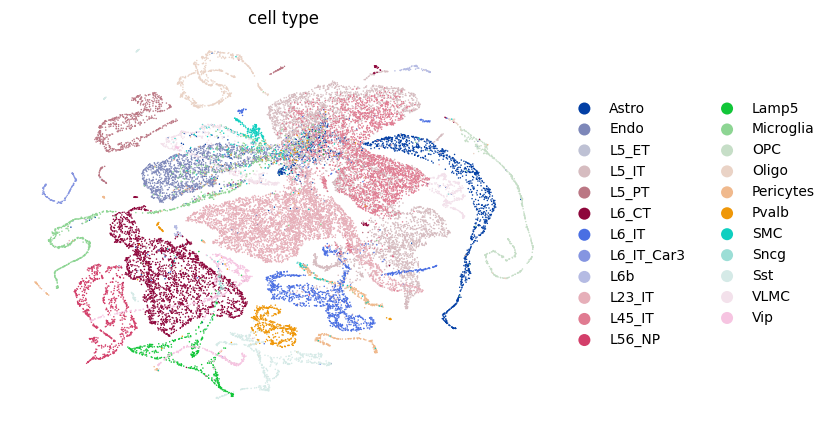

In [25]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.scatter(adata, basis='umap', color=['cell_type'], frameon=False)

In [26]:
raw_ad=sc.AnnData(adata.X)
raw_ad.obs_names, raw_ad.var_names=adata.obs_names, adata.var_names
adata.raw=raw_ad
sc.pp.highly_variable_genes(adata, n_top_genes=1500)


In [28]:
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)

In [31]:
#Construct kernel matrix
import SEACells
n_SEACells=100 
build_kernel_on='X_pca'
n_waypoint_eigs=10

In [33]:
model= SEACells.core.SEACells(adata, 
                              build_kernel_on= build_kernel_on,
                              n_SEACells=n_SEACells,
                              n_waypoint_eigs=n_waypoint_eigs,
                              convergence_epsilon=1e-5
                              )

Welcome to SEACells!


In [34]:
model.construct_kernel_matrix()
M=model.kernel_matrix

Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/25932 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/25932 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/25932 [00:00<?, ?it/s]

Constructing CSR matrix...


In [35]:
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 91 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 19/19 [00:03<00:00,  5.15it/s]

Selecting 9 cells from greedy initialization.


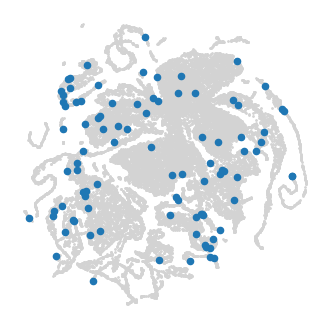

In [36]:
SEACells.plot.plot_initialization(adata, model)

In [37]:
model.fit(min_iter=10, max_iter=30)
print (f'Ran for {len(model.RSS_iters)} iterations')

Randomly initialized A matrix.
Setting convergence threshold at nan
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.


KeyboardInterrupt: 

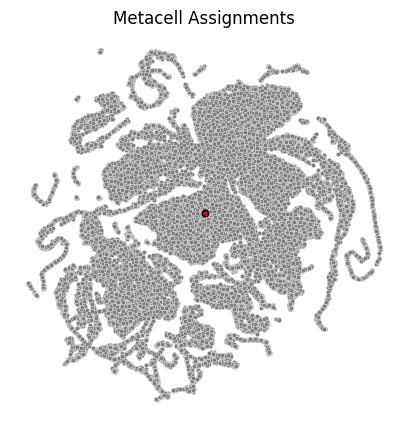

In [38]:
SEACells.plot.plot_2D(adata, colour_metacells=False)

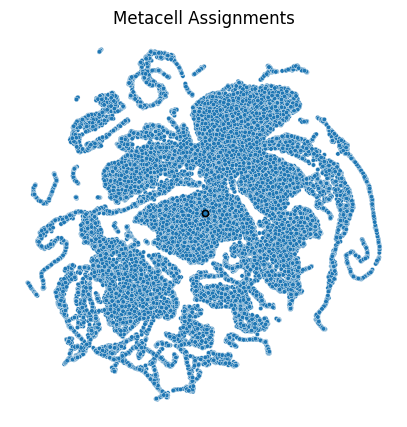

In [40]:
SEACells.plot.plot_2D(adata, colour_metacells=True)